In [100]:
!pip install  ipympl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 341.2 kB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 597.2 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipympl]2m3/4 [ipympl]ets]widgets]


In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


In [15]:
def is_graph_connected(filename):
    G = nx.Graph()                     # undirected graph

    with open(filename, 'r') as f:
        # Skip header line
        next(f)

        for line_num, line in enumerate(f, 2):          # line_num starts at 2
            parts = line.strip().split()
            if len(parts) != 3:
                print(f"Warning: malformed line {line_num}: {line.strip()}")
                continue

            src = int(parts[0])
            dst = int(parts[1])
            weight = float(parts[2])   # you can keep it if you want

            G.add_edge(src, dst)       # undirected → adds both directions

    print(f"Loaded {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")

    if nx.is_connected(G):
        print("The graph IS CONNECTED")
        return True
    else:
        print("The graph is NOT connected")
        print(f"Number of connected components: {nx.number_connected_components(G)}")
        return False



In [8]:
G = nx.read_edgelist("mosp.csv", data=[("weight", float)], create_using=nx.Graph())
print("Connected" if nx.is_connected(G) else "NOT connected")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Connected
Nodes: 15324, Edges: 19348


In [75]:
EDGE_FILE = "mosp.csv"              # Src Dest Weight (your original file)
DIJKSTRA_FILE = "sosp.csv"  # Vertex Distance Parent
SOURCE_NODE = 0                      # usually 0, change if different
NUM_VERTICES = 15127                 # total number of vertices in the graph

In [80]:
G = nx.Graph()
with open(EDGE_FILE, 'r') as f:
    # next(f)  # skip header
    print("Reading edges...")
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 2: continue
        u, v = int(parts[0]), int(parts[1])
        w = float(parts[2]) if len(parts) > 2 else 1.0
        G.add_edge(u, v, weight=w)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Reading edges...
Graph: 15324 nodes, 19348 edges


In [81]:
parent = {}
distance = {}
with open(DIJKSTRA_FILE, 'r') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split()
        if len(parts) != 3: continue
        v = int(parts[0])
        dist = int(parts[1])
        par = int(parts[2])
        distance[v] = dist
        parent[v] = par if par != -1 else None

print(f"Dijkstra tree loaded from source =", SOURCE_NODE)
# Extract tree edges: (child → parent)
tree_edges = [(child, par) for child, par in parent.items() if par is not None]

Dijkstra tree loaded from source = 0


In [63]:
# Load mapping
with open("osm_mapping.pkl", "rb") as f:
    data = pickle.load(f)

reverse_map = data['new_to_old']
coords = data['coords_raw']  # or use data['coords_raw'] for real map

# Create positions dict for networkx
pos = {i: coords[i] for i in range(len(coords))}

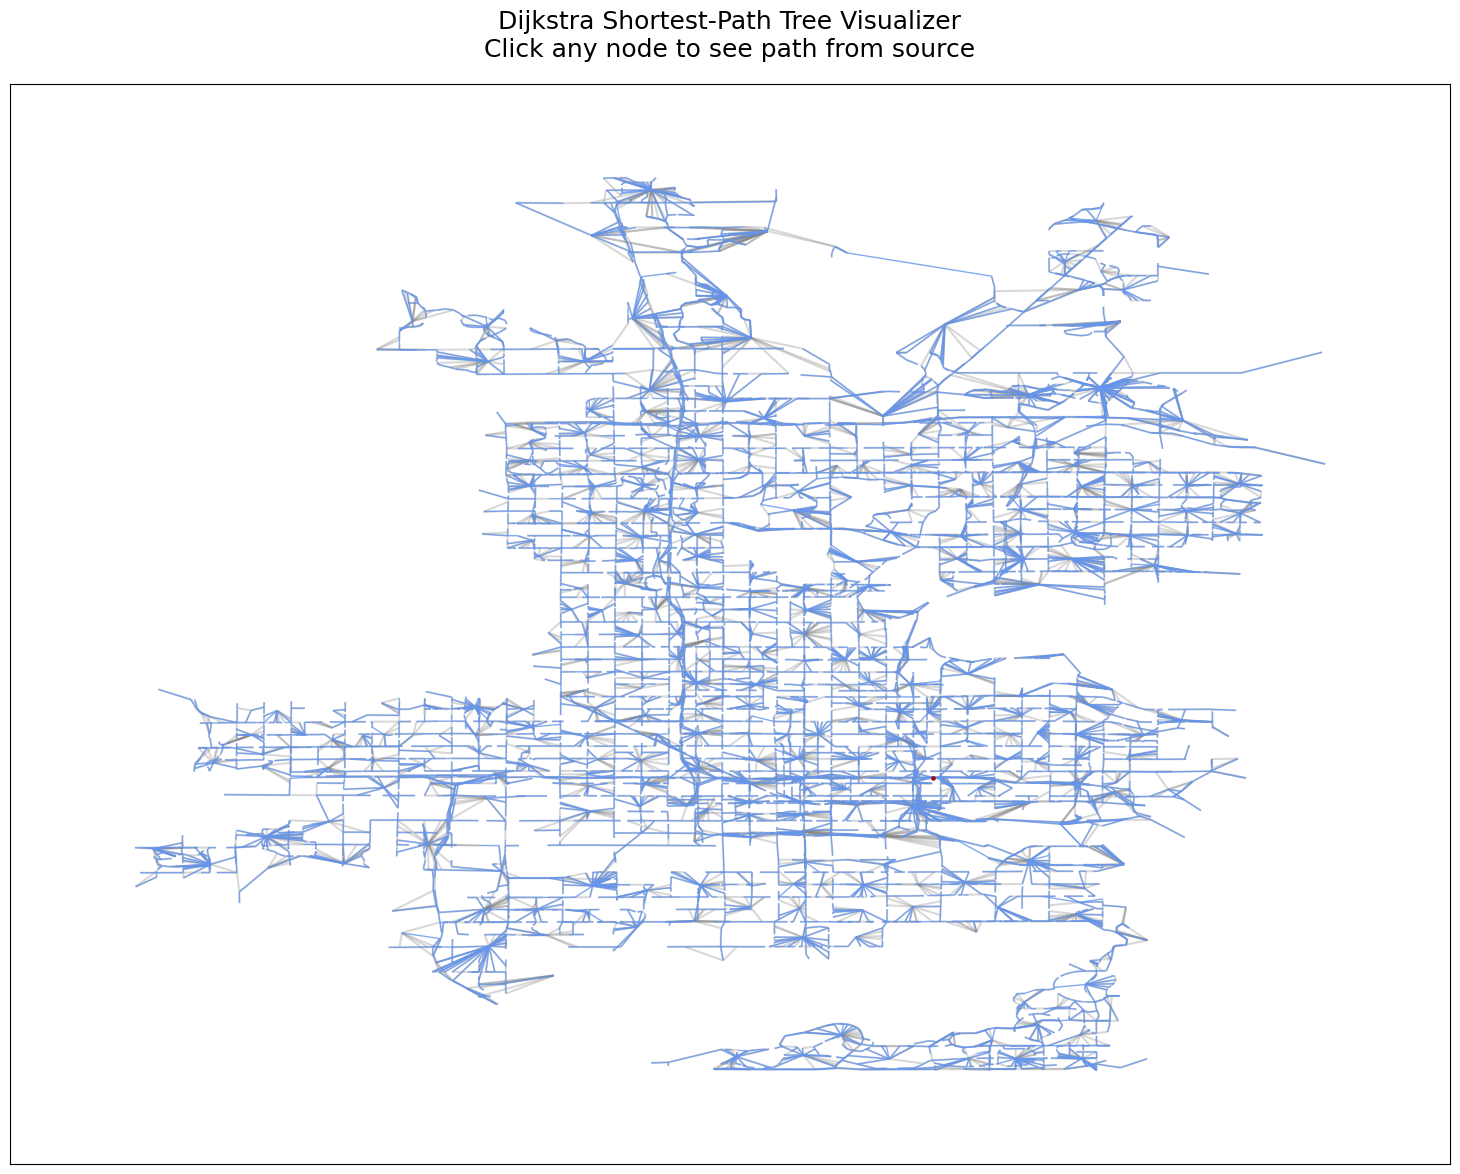

In [127]:
# Setup plot
fig, ax = plt.subplots(figsize=(16, 12))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
ax.set_title("Dijkstra Shortest-Path Tree Visualizer\nClick any node to see path from source", 
             fontsize=18, pad=20)

# Draw all graph edges (very light)
nx.draw_networkx_edges(G, pos, width=1.5, edge_color='gray',alpha=0.3)

# Draw tree edges (blue, thicker)
tree_edge_collection = nx.draw_networkx_edges(
    G, pos, edgelist=tree_edges, width=1, alpha=0.8, edge_color='cornflowerblue'
)


# # Draw all nodes
# nodes = nx.draw_networkx_nodes(G, pos, node_size=0.1, node_color='black', 
#                                edgecolors='black', linewidths=2)

# Highlight source
nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='red', 
                       node_size=5, edgecolors='darkred', linewidths=1)

PATH:  [234, 235, 232, 231, 233, 2594, 230, 224, 222, 226, 14339, 4301, 164, 166, 4303, 4305, 5184, 195, 190, 189, 188, 207, 209, 205, 206, 163, 160, 162, 204, 159, 157, 158, 172, 173, 15052, 14114, 14103, 7744, 391, 393, 15144, 1770, 6492, 1768, 15123, 8522, 8523, 8555, 8556, 8557, 8560, 8561, 8562, 15124, 0]
Parent:  15
Path to 234: 0 → 15124 → 8562 → 8561 → 8560 → 8557 → 8556 → 8555 → 8523 → 8522 → 15123 → 1768 → 6492 → 1770 → 15144 → 393 → 391 → 7744 → 14103 → 14114 → 15052 → 173 → 172 → 158 → 157 → 159 → 204 → 162 → 160 → 163 → 206 → 205 → 209 → 207 → 188 → 189 → 190 → 195 → 5184 → 4305 → 4303 → 166 → 164 → 4301 → 14339 → 226 → 222 → 224 → 230 → 2594 → 233 → 231 → 232 → 235 → 234 (dist = 6166)


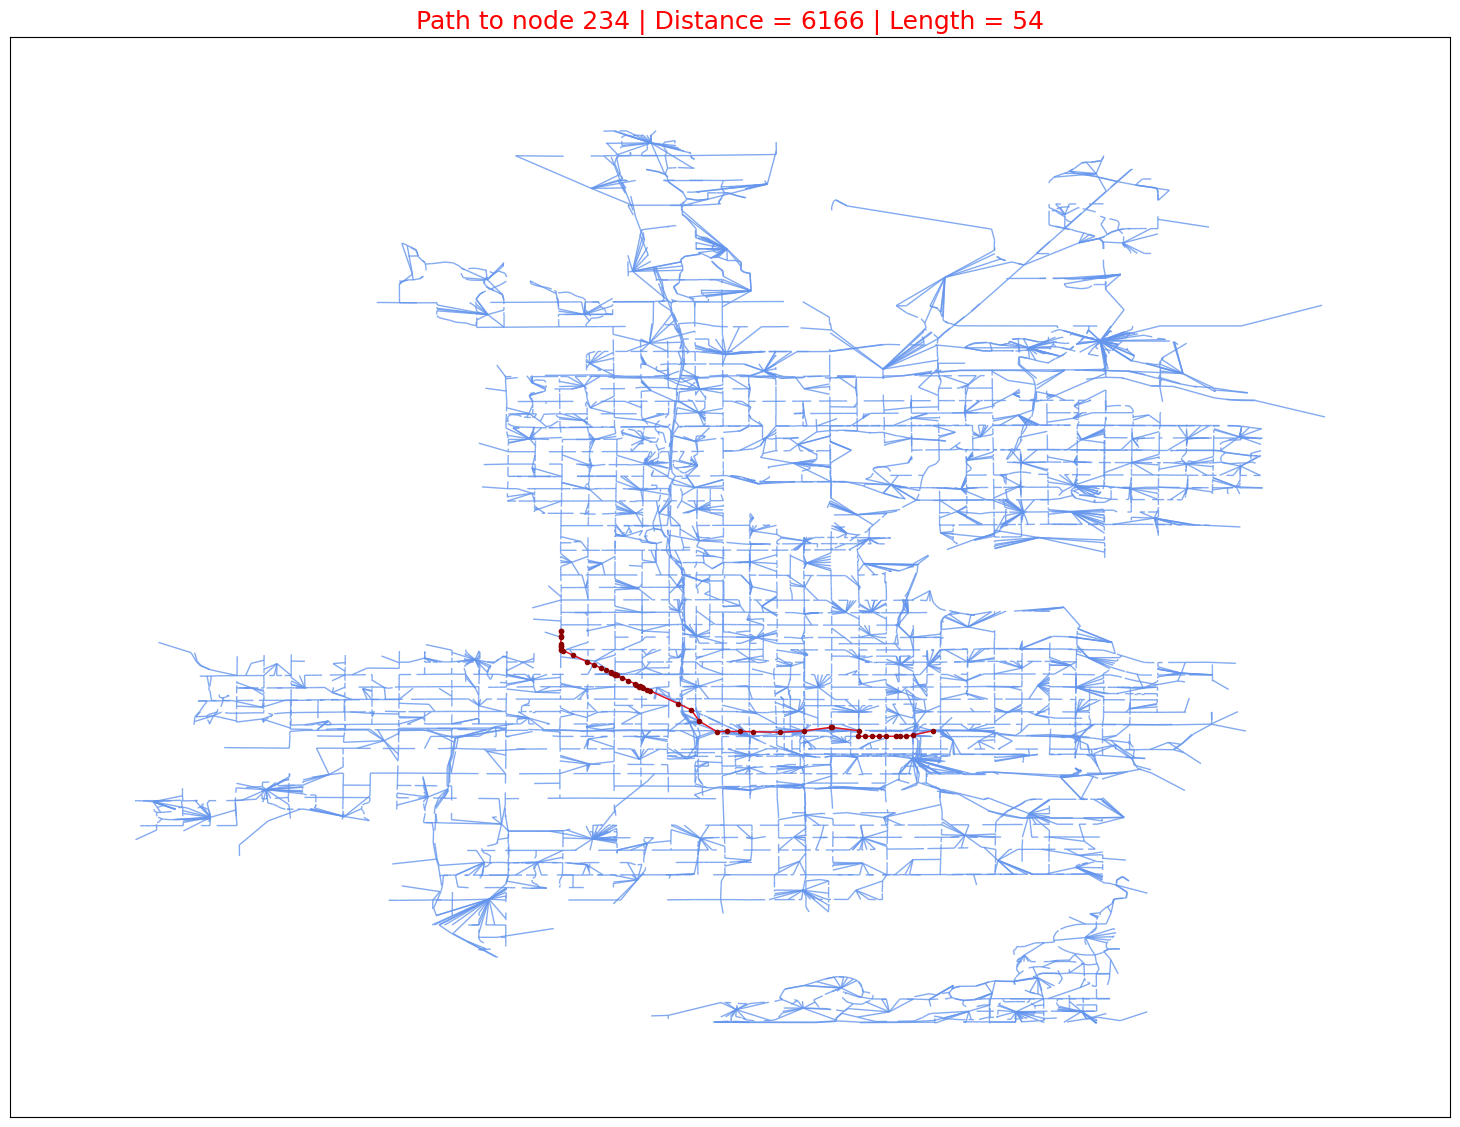

In [109]:
# Setup plot
fig, ax = plt.subplots(figsize=(16, 12))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

# Draw tree edges (blue, thicker)
tree_edge_collection = nx.draw_networkx_edges(
    G, pos, edgelist=tree_edges, width=1, alpha=0.8, edge_color='cornflowerblue'
)

# Store current path highlight objects
current_path_edges = []
current_path_nodes = []

def clear_highlight():
    global current_path_edges, current_path_nodes
    for item in current_path_edges + current_path_nodes:
        item.remove()
    current_path_edges.clear()
    current_path_nodes.clear()

def highlight_path_to(target_node):
    clear_highlight()
    
    # Reconstruct path: target → parent → parent → ... → source
    path = []
    current = target_node
    while current is not None:
        path.append(current)
        if current == SOURCE_NODE:
            break
        current = parent.get(current)
        
    print("PATH: ", path)
    print("Parent: ", parent[10])
    
    if path[-1] != SOURCE_NODE:
        print(f"No path from source to node {target_node}")
        return
    
    path.reverse()  # source → target
    print(f"Path to {target_node}: {' → '.join(map(str, path))} (dist = {distance[target_node]})")

    # Highlight path edges
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=1, 
                           edge_color='red', alpha=0.9)

    # Highlight path nodes
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='red', 
                           node_size=4, edgecolors='darkred', linewidths=2)

    # Labels on path
    # labels = {n: f"{n}\n{distance[n]}" for n in path}
    # nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white', 
                            # font_weight='bold')

    ax.set_title(f"Path to node {target_node} | Distance = {distance[target_node]} | Length = {len(path)-1}",
                 fontsize=18, color='red')
    plt.draw()

# Click handler
def on_click(event):
    if event.inaxes != ax or event.button != 1:
        return
    
    x, y = event.xdata, event.ydata
    if x is None or y is None:
        return

    # Find closest node
    closest = min(G.nodes(), key=lambda n: (pos[n][0]-x)**2 + (pos[n][1]-y)**2)
    dist = np.hypot(pos[closest][0]-x, pos[closest][1]-y)
    
    if dist < 0.03:  # adjust sensitivity
        highlight_path_to(closest)

# Initial display
highlight_path_to(234)  # show tree root on start
fig.canvas.mpl_connect('button_press_event', on_click)

plt.show()

In [ ]:
# remap_coords_from_csv.py
import pandas as pd
import numpy as np
import pickle

CSV_FILE = "node.csv"   # your file with Node_ID Lon Lat

print("Loading your node coordinates CSV...")
df = pd.read_csv(CSV_FILE)

# Sort by old Node_ID to ensure deterministic order (important!)
df = df.sort_values('Node_ID').reset_index(drop=True)

old_ids = df['Node_ID'].values
lons = df['Lon'].values
lats = df['Lat'].values

num_nodes = len(df)
print(f"Loaded {num_nodes} nodes")

# Create mapping: old_id → new_contiguous_id (0,1,2,...)
old_to_new = {old_id: new_id for new_id, old_id in enumerate(old_ids)}

# Create coordinates for NEW contiguous IDs (0..N-1)
coords_raw = np.column_stack((lons, lats))  # shape: (N, 2)

# Scale to 0–100 for nice plotting
lon_min, lat_min = coords_raw.min(axis=0)
lon_max, lat_max = coords_raw.max(axis=0)

# Save everything
mapping_data = {
    'old_to_new': old_to_new,                    # old_id → 0..N-1
    'new_to_old': dict(enumerate(old_ids)),      # 0..N-1 → old_id
    'coords_raw': coords_raw,                    # real lon/lat
    'num_vertices': num_nodes,
    'bounds': (lon_min, lon_max, lat_min, lat_max)
}

with open("osm_mapping.pkl", "wb") as f:
    pickle.dump(mapping_data, f)

print(f"SUCCESS: Saved mapping for {num_nodes} nodes")
print("    → Your C program's node 0..N-1 now have real coordinates!")
print("    → Use final_visualizer.py next")

Loading your node coordinates CSV...
Loaded 15324 nodes
SUCCESS: Saved mapping for 15324 nodes
    → Your C program's node 0..N-1 now have real coordinates!
    → Use final_visualizer.py next
